# HW8

This notebook trains a classifier that estimates whether a user was likely acquired through a paid campaign or appeared as organic. The data comes from `dataset_academy.pickle`, each row represents one user, and the final section saves the winning model as a pickle artifact.

## Setup

In [1]:
from pathlib import Path
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except Exception:
    HAS_CATBOOST = False

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

ROOT = Path.cwd()
if not (ROOT / 'dataset_academy.pickle').exists() and (ROOT / 'HW8' / 'dataset_academy.pickle').exists():
    ROOT = ROOT / 'HW8'

DATA_PATH = ROOT / 'dataset_academy.pickle'
ARTIFACT_DIR = ROOT / 'artifacts'
ARTIFACT_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42

HAS_XGBOOST, HAS_CATBOOST


(True, True)

## Load the dataset

The provided file is a pandas DataFrame stored as a pickle. Each row is one user, the action columns are 30-day averages after install, and the `campaign` column is used to derive the target.

In [2]:
with DATA_PATH.open('rb') as f:
    df = pickle.load(f)

df = df.copy()
df['is_paid'] = (df['campaign'] != '<organic>').astype(int)
df.head()


,user_id,avg_open_team,avg_open_event,avg_open_league,avg_open_player,avg_open_matches,avg_open_lineups,avg_open_sport,avg_open_overs,avg_open_fight_night,avg_open_stage,avg_follow_team,avg_follow_player,avg_follow_league,avg_chat_activity,avg_chat_action,avg_ads_impression_custom,avg_odds_impression,avg_total_screen_time,avg_num_distinct_events,geo_country,campaign,is_paid
28648,2e26d3769e9311c8dba02ba7376f9c03,0.0645,0.4839,0.0645,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.7419,0.4516,41859.2581,2.1290,Brazil,And_GA_BR_valuable_cpc,1
120343,c2bf754aa582c17b29f0d7e57aaadcce,0.0000,0.8387,0.0645,0.1290,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.1290,120081.4194,1.0645,Gambia,<organic>,0
41493,4301ff35fa086ec4bd8749f73d40b6d0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,182.8710,0.1290,Brazil,And_MO_WW_Install,1
96883,9cdf7f4b1cc627bec3d8c300cff9aeb2,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0645,0.0000,2561.5161,0.2581,Cameroon,And_GA_T3_valuable_cpc_#2,1
15991,19b54af703e02258094b15067058e64c,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0968,0.0000,63684.7097,2.5806,Haiti,<organic>,0


In [3]:
print('shape:', df.shape)
print('missing values:', int(df.isna().sum().sum()))
print('paid share:', df['is_paid'].mean())
print('unique countries:', df['geo_country'].nunique())
print('top countries:')
display(df['geo_country'].value_counts().head(15).to_frame('users'))
print('top campaigns:')
display(df['campaign'].value_counts().head(15).to_frame('users'))


shape: (126870, 23)
missing values: 0
paid share: 0.5664223220619532
unique countries: 195
top countries:


,users
geo_country,
Brazil,15369
Morocco,8186
Nigeria,6691
Haiti,5717
Italy,4415
India,4230
Indonesia,4223
Tanzania,3759
Kenya,3088


top campaigns:


,users
campaign,
<organic>,55008
And_GA_BR_valuable_cpc,10518
And_GA_T3_valuable_cpc_#2,8546
And_GA_WW_Install_valuable_cpc,4703
And_GA_T1_valuable_cpc_#2,3760
And_GA_T2_valuable_cpc,2392
And_GA_ID_valuable_cpc,2296
And_LO_NG_install,2280
And_GA_MA_15_odds_impr,2124


## Target definition

I treat every non-`<organic>` record as a paid user. The organic class is probably a bit noisy, so later I tune the decision threshold on validation data instead of forcing the default 0.5 cutoff.

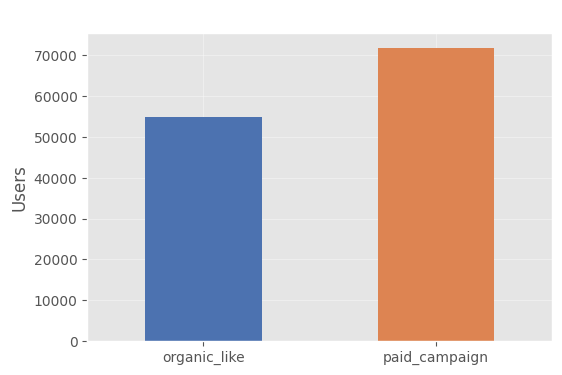

In [4]:
target_counts = df['is_paid'].value_counts().sort_index()
target_counts.index = ['organic_like', 'paid_campaign']

fig, ax = plt.subplots(figsize=(6, 4))
target_counts.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_title('Target balance')
ax.set_ylabel('Users')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.show()


In [5]:
numeric_features = [col for col in df.columns if col.startswith('avg_')]
categorical_features = ['geo_country']

summary = df[numeric_features].describe().T[['mean', 'std', 'min', 'max']].sort_values('mean', ascending=False)
display(summary.head(12))

zero_share = (df[numeric_features] == 0).mean().sort_values(ascending=False)
display(zero_share.head(12).to_frame('zero_share'))


,mean,std,min,max
avg_total_screen_time,127449.0848,402246.7889,0.0000,17862854.0968
avg_ads_impression_custom,5.8425,20.7032,0.0000,1318.8387
avg_odds_impression,2.8135,13.4915,0.0000,993.2903
avg_open_event,2.3426,9.5708,0.0000,591.6774
avg_num_distinct_events,2.1092,3.0330,0.0000,24.9355
avg_open_team,0.2894,1.8121,0.0000,137.4839
avg_open_player,0.1453,1.1806,0.0000,99.7097
avg_open_league,0.1445,0.5932,0.0000,48.9032
avg_chat_activity,0.1422,1.7396,0.0000,148.7419
avg_follow_team,0.0483,0.3504,0.0000,24.3871


,zero_share
avg_open_overs,1.0000
avg_open_sport,0.9998
avg_open_fight_night,0.9977
avg_open_stage,0.9976
avg_chat_action,0.9963
avg_open_matches,0.9856
avg_open_lineups,0.9842
avg_follow_player,0.9651
avg_follow_league,0.9418
avg_chat_activity,0.8547


## Split

I keep a final holdout test split and use a validation split for model selection and threshold tuning. That keeps the final test metrics separate from the model choice.

In [6]:
X = df.drop(columns=['user_id', 'campaign', 'is_paid'])
y = df['is_paid']

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    stratify=y_train_full,
    random_state=RANDOM_STATE,
)

print('train:', X_train.shape, y_train.mean())
print('validation:', X_val.shape, y_val.mean())
print('test:', X_test.shape, y_test.mean())


train: (76122, 20) 0.5664328315073172
validation: (25374, 20) 0.5664065578939071
test: (25374, 20) 0.5664065578939071


## Helpers

In [7]:
def make_preprocessor(scale_numeric: bool = False):
    numeric_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale_numeric:
        numeric_steps.append(('scaler', StandardScaler()))
    numeric_pipe = Pipeline(numeric_steps)

    categorical_pipe = Pipeline(
        [
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]
    )
    return ColumnTransformer(
        [
            ('num', numeric_pipe, numeric_features),
            ('cat', categorical_pipe, categorical_features),
        ]
    )

def tune_threshold(y_true, prob, lower=0.2, upper=0.8, steps=61):
    thresholds = np.linspace(lower, upper, steps)
    best_threshold = 0.5
    best_f1 = -1.0
    for threshold in thresholds:
        pred = (prob >= threshold).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > best_f1:
            best_threshold = float(threshold)
            best_f1 = float(f1)
    return best_threshold, best_f1

def score_paid_class(y_true, y_pred):
    return {
        'precision_paid': precision_score(y_true, y_pred, zero_division=0),
        'recall_paid': recall_score(y_true, y_pred, zero_division=0),
        'f1_paid': f1_score(y_true, y_pred, zero_division=0),
    }

def score_paid_only_subset(y_true, y_pred):
    mask = y_true == 1
    subset_true = y_true[mask]
    subset_pred = y_pred[mask]
    return {
        'paid_only_precision': precision_score(subset_true, subset_pred, zero_division=0),
        'paid_only_recall': recall_score(subset_true, subset_pred, zero_division=0),
        'paid_only_f1': f1_score(subset_true, subset_pred, zero_division=0),
        'paid_only_size': int(mask.sum()),
    }

def evaluate_predictions(y_true, y_pred):
    row = {}
    row.update(score_paid_class(y_true, y_pred))
    row.update(score_paid_only_subset(y_true, y_pred))
    return row

def cv_f1_summary(X_data, y_data):
    model = Pipeline(
        [
            ('prep', make_preprocessor(scale_numeric=True)),
            ('model', LogisticRegression(max_iter=1500, class_weight='balanced', solver='liblinear')),
        ]
    )
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for train_idx, valid_idx in skf.split(X_data, y_data):
        X_tr = X_data.iloc[train_idx]
        y_tr = y_data.iloc[train_idx]
        X_va = X_data.iloc[valid_idx]
        y_va = y_data.iloc[valid_idx]
        model.fit(X_tr, y_tr)
        pred = model.predict(X_va)
        scores.append(f1_score(y_va, pred, zero_division=0))
    return {'cv_f1_mean': float(np.mean(scores)), 'cv_f1_std': float(np.std(scores))}


## Model candidates

I compare a few model types. The linear model is a baseline, tree models are a better fit for sparse behavior features, and CatBoost is especially convenient because `geo_country` has many levels.

In [8]:
results = []
trained_models = {}

def evaluate_pipeline_model(name, estimator, scale_numeric=False):
    model = Pipeline([('prep', make_preprocessor(scale_numeric=scale_numeric)), ('model', estimator)])
    model.fit(X_train, y_train)
    val_prob = model.predict_proba(X_val)[:, 1]
    threshold, val_f1 = tune_threshold(y_val, val_prob)
    test_prob = model.predict_proba(X_test)[:, 1]
    test_pred = (test_prob >= threshold).astype(int)
    row = {'model': name, 'threshold': threshold, 'val_f1_paid': val_f1}
    row.update(evaluate_predictions(y_test, test_pred))
    trained_models[name] = model
    results.append(row)

evaluate_pipeline_model(
    'dummy_most_frequent',
    DummyClassifier(strategy='most_frequent'),
)

evaluate_pipeline_model(
    'logistic_regression',
    LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear'),
    scale_numeric=True,
)

evaluate_pipeline_model(
    'random_forest',
    RandomForestClassifier(
        n_estimators=250,
        min_samples_leaf=2,
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=4,
    ),
)


In [9]:
hist_prep = ColumnTransformer(
    [
        ('num', SimpleImputer(strategy='median'), numeric_features),
        (
            'cat',
            Pipeline(
                [
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('onehot', OneHotEncoder(handle_unknown='ignore')),
                ]
            ),
            categorical_features,
        ),
    ]
)

X_train_hist = hist_prep.fit_transform(X_train)
X_val_hist = hist_prep.transform(X_val)
X_test_hist = hist_prep.transform(X_test)
if hasattr(X_train_hist, 'toarray'):
    X_train_hist = X_train_hist.toarray()
    X_val_hist = X_val_hist.toarray()
    X_test_hist = X_test_hist.toarray()

hist_model = HistGradientBoostingClassifier(
    max_depth=6,
    learning_rate=0.05,
    max_iter=400,
    min_samples_leaf=30,
    random_state=RANDOM_STATE,
)
hist_model.fit(X_train_hist, y_train)
hist_val_prob = hist_model.predict_proba(X_val_hist)[:, 1]
hist_threshold, hist_val_f1 = tune_threshold(y_val, hist_val_prob)
hist_test_prob = hist_model.predict_proba(X_test_hist)[:, 1]
hist_test_pred = (hist_test_prob >= hist_threshold).astype(int)
row = {'model': 'hist_gradient_boosting', 'threshold': hist_threshold, 'val_f1_paid': hist_val_f1}
row.update(evaluate_predictions(y_test, hist_test_pred))
trained_models['hist_gradient_boosting'] = (hist_prep, hist_model)
results.append(row)


In [10]:
if HAS_XGBOOST:
    xgb_prep = ColumnTransformer(
        [
            ('num', SimpleImputer(strategy='median'), numeric_features),
            (
                'cat',
                Pipeline(
                    [
                        ('imputer', SimpleImputer(strategy='most_frequent')),
                        ('onehot', OneHotEncoder(handle_unknown='ignore')),
                    ]
                ),
                categorical_features,
            ),
        ]
    )
    X_train_xgb = xgb_prep.fit_transform(X_train)
    X_val_xgb = xgb_prep.transform(X_val)
    X_test_xgb = xgb_prep.transform(X_test)
    scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
    xgb_model = XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        min_child_weight=2,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=4,
        scale_pos_weight=scale_pos_weight,
    )
    xgb_model.fit(X_train_xgb, y_train)
    xgb_val_prob = xgb_model.predict_proba(X_val_xgb)[:, 1]
    xgb_threshold, xgb_val_f1 = tune_threshold(y_val, xgb_val_prob)
    xgb_test_prob = xgb_model.predict_proba(X_test_xgb)[:, 1]
    xgb_test_pred = (xgb_test_prob >= xgb_threshold).astype(int)
    row = {'model': 'xgboost', 'threshold': xgb_threshold, 'val_f1_paid': xgb_val_f1}
    row.update(evaluate_predictions(y_test, xgb_test_pred))
    trained_models['xgboost'] = (xgb_prep, xgb_model)
    results.append(row)
else:
    print('xgboost is not available in this environment, so I skipped it.')


In [11]:
if HAS_CATBOOST:
    catboost_model = CatBoostClassifier(
        loss_function='Logloss',
        eval_metric='F1',
        iterations=600,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=5.0,
        random_seed=RANDOM_STATE,
        verbose=False,
        auto_class_weights='Balanced',
        allow_writing_files=False,
    )
    catboost_model.fit(
        X_train,
        y_train,
        cat_features=categorical_features,
        eval_set=(X_val, y_val),
        use_best_model=True,
    )
    cat_val_prob = catboost_model.predict_proba(X_val)[:, 1]
    cat_threshold, cat_val_f1 = tune_threshold(y_val, cat_val_prob)
    cat_test_prob = catboost_model.predict_proba(X_test)[:, 1]
    cat_test_pred = (cat_test_prob >= cat_threshold).astype(int)
    row = {'model': 'catboost', 'threshold': cat_threshold, 'val_f1_paid': cat_val_f1}
    row.update(evaluate_predictions(y_test, cat_test_pred))
    trained_models['catboost'] = catboost_model
    results.append(row)
else:
    print('catboost is not available in this environment, so I skipped it.')


## Comparison

In [12]:
results_df = pd.DataFrame(results).sort_values(
    ['f1_paid', 'recall_paid', 'precision_paid'],
    ascending=False,
).reset_index(drop=True)
display(results_df)
cv_summary = cv_f1_summary(X_train_full, y_train_full)
cv_summary


,model,threshold,val_f1_paid,precision_paid,recall_paid,f1_paid,paid_only_precision,paid_only_recall,paid_only_f1,paid_only_size
0,catboost,0.4000,0.8211,0.7282,0.9420,0.8214,1.0000,0.9420,0.9701,14372
1,xgboost,0.3700,0.8185,0.7186,0.9571,0.8209,1.0000,0.9571,0.9781,14372
2,hist_gradient_boosting,0.4500,0.8164,0.7175,0.9557,0.8196,1.0000,0.9557,0.9773,14372
3,random_forest,0.4200,0.8163,0.7257,0.9361,0.8176,1.0000,0.9361,0.9670,14372
4,logistic_regression,0.3200,0.7958,0.6796,0.9555,0.7943,1.0000,0.9555,0.9773,14372
5,dummy_most_frequent,0.2000,0.7232,0.5664,1.0000,0.7232,1.0000,1.0000,1.0000,14372


{'cv_f1_mean': 0.7753582011116313, 'cv_f1_std': 0.0023978008244940697}

The paid class is the one I care about most here because those users are known campaign users whenever `campaign != <organic>`. That is why the threshold is tuned for paid-class F1 instead of relying on the default cutoff.

In [13]:
best_row = results_df.iloc[0]
best_model_name = best_row['model']
best_threshold = float(best_row['threshold'])
best_model_name, best_threshold


('catboost', 0.4)

## Final evaluation on the holdout test split

In [14]:
if best_model_name == 'catboost':
    best_test_prob = trained_models['catboost'].predict_proba(X_test)[:, 1]
elif best_model_name == 'xgboost':
    xgb_prep, xgb_model = trained_models['xgboost']
    X_test_best = xgb_prep.transform(X_test)
    best_test_prob = xgb_model.predict_proba(X_test_best)[:, 1]
elif best_model_name == 'hist_gradient_boosting':
    hist_prep, hist_model = trained_models['hist_gradient_boosting']
    X_test_best = hist_prep.transform(X_test)
    if hasattr(X_test_best, 'toarray'):
        X_test_best = X_test_best.toarray()
    best_test_prob = hist_model.predict_proba(X_test_best)[:, 1]
else:
    best_test_prob = trained_models[best_model_name].predict_proba(X_test)[:, 1]

best_test_pred = (best_test_prob >= best_threshold).astype(int)
print(classification_report(y_test, best_test_pred, digits=4))
pd.DataFrame(
    confusion_matrix(y_test, best_test_pred),
    index=['actual_organic_like', 'actual_paid'],
    columns=['pred_organic_like', 'pred_paid'],
)


              precision    recall  f1-score   support

           0     0.8770    0.5407    0.6690     11002
           1     0.7282    0.9420    0.8214     14372

    accuracy                         0.7680     25374
   macro avg     0.8026    0.7413    0.7452     25374
weighted avg     0.7927    0.7680    0.7553     25374



,pred_organic_like,pred_paid
actual_organic_like,5949,5053
actual_paid,834,13538


The brief also asks for evaluation on users that are definitely campaign users. In this dataset that is the subset where `campaign != <organic>`. On that slice, recall is the main number to watch because the slice contains only paid users.

In [15]:
paid_only_mask = y_test == 1
paid_only_report = {
    'precision_on_paid_only_slice': precision_score(y_test[paid_only_mask], best_test_pred[paid_only_mask], zero_division=0),
    'recall_on_paid_only_slice': recall_score(y_test[paid_only_mask], best_test_pred[paid_only_mask], zero_division=0),
    'f1_on_paid_only_slice': f1_score(y_test[paid_only_mask], best_test_pred[paid_only_mask], zero_division=0),
    'paid_only_size': int(paid_only_mask.sum()),
}
paid_only_report


{'precision_on_paid_only_slice': 1.0,
 'recall_on_paid_only_slice': 0.9419704981909268,
 'f1_on_paid_only_slice': 0.970118237190971,
 'paid_only_size': 14372}

## Country diagnostic

I checked the best model by country to see whether separate country models would clearly help. Some countries are much easier than others, mostly because the paid share is very different, but the single global model is still the cleaner choice for this homework.

In [16]:
country_eval = X_test[['geo_country']].copy()
country_eval['is_paid'] = y_test.to_numpy()
country_eval['pred_paid'] = best_test_pred

country_rows = []
for country, group in country_eval.groupby('geo_country'):
    if len(group) < 200:
        continue
    country_rows.append(
        {
            'geo_country': country,
            'users': len(group),
            'paid_rate': group['is_paid'].mean(),
            'f1_paid': f1_score(group['is_paid'], group['pred_paid'], zero_division=0),
            'precision_paid': precision_score(group['is_paid'], group['pred_paid'], zero_division=0),
            'recall_paid': recall_score(group['is_paid'], group['pred_paid'], zero_division=0),
        }
    )

country_results = pd.DataFrame(country_rows).sort_values('f1_paid')
display(country_results.head(10))
display(country_results.sort_values('f1_paid', ascending=False).head(10))


,geo_country,users,paid_rate,f1_paid,precision_paid,recall_paid
13,Haiti,1163,0.0077,0.0000,0.0000,0.0000
8,Egypt,209,0.0813,0.0000,0.0000,0.0000
28,Türkiye,426,0.0399,0.0000,0.0000,0.0000
2,Bangladesh,408,0.3554,0.5192,0.4536,0.6069
30,United Kingdom,312,0.4872,0.7139,0.5681,0.9605
10,Germany,288,0.5104,0.7297,0.6054,0.9184
14,India,925,0.3762,0.7473,0.6497,0.8793
31,United States,289,0.5536,0.7481,0.6224,0.9375
24,South Africa,448,0.5893,0.7625,0.6220,0.9848
9,France,383,0.5248,0.7670,0.6549,0.9254


,geo_country,users,paid_rate,f1_paid,precision_paid,recall_paid
19,Morocco,1615,0.8254,0.9220,0.8637,0.9887
21,Peru,250,0.8080,0.9116,0.8410,0.9950
1,Azerbaijan,291,0.7904,0.8959,0.8172,0.9913
4,Burkina Faso,333,0.7658,0.8818,0.8013,0.9804
32,Zambia,310,0.7355,0.8745,0.7908,0.9781
3,Brazil,3018,0.7449,0.8680,0.7743,0.9875
17,Kenya,620,0.7226,0.8530,0.7526,0.9844
23,Serbia,316,0.6646,0.8506,0.7537,0.9762
29,Uganda,224,0.7098,0.8453,0.7537,0.9623
26,Tanzania,734,0.6894,0.8428,0.7392,0.9802


## Feature importance for the best model

This section is shown only if the winning model exposes feature importance directly.

,feature,importance
19,geo_country,40.4925
17,avg_total_screen_time,20.0241
5,avg_open_lineups,10.5351
18,avg_num_distinct_events,10.1517
4,avg_open_matches,8.2748
15,avg_ads_impression_custom,4.2278
1,avg_open_event,1.4241
13,avg_chat_activity,1.2424
16,avg_odds_impression,0.8794
3,avg_open_player,0.6824


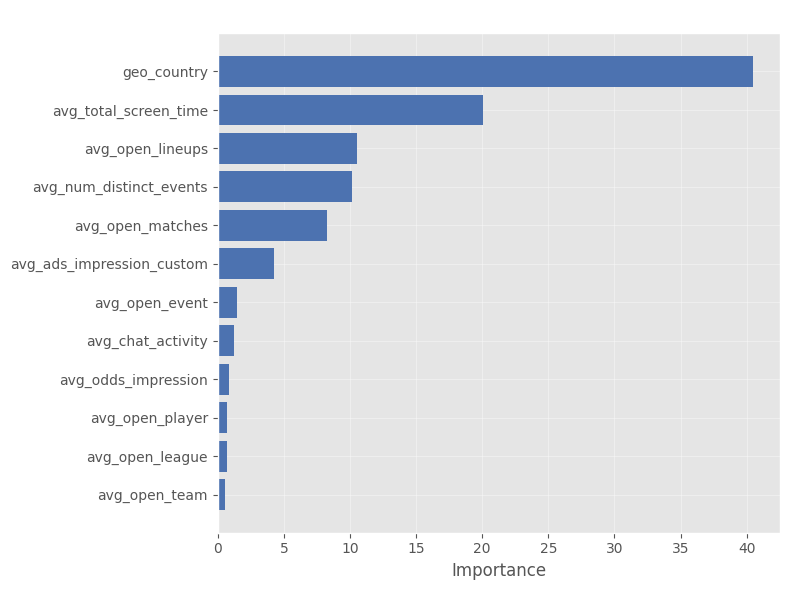

In [17]:
if best_model_name == 'catboost':
    importances = pd.DataFrame(
        {
            'feature': trained_models['catboost'].feature_names_,
            'importance': trained_models['catboost'].get_feature_importance(),
        }
    ).sort_values('importance', ascending=False)
    display(importances.head(15))

    fig, ax = plt.subplots(figsize=(8, 6))
    top_importances = importances.head(12).iloc[::-1]
    ax.barh(top_importances['feature'], top_importances['importance'], color='#4C72B0')
    ax.set_title('Top CatBoost feature importances')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print('Feature importance is shown only for the CatBoost winner in this notebook.')


## Refit the winner on all available data

After the comparison is done, I retrain the winning configuration on the full dataset and save a pickle artifact. The saved object contains the fitted model, the threshold, and the feature metadata needed for reuse.

In [18]:
final_artifact = None

if best_model_name == 'catboost':
    final_model = CatBoostClassifier(
        loss_function='Logloss',
        eval_metric='F1',
        iterations=600,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=5.0,
        random_seed=RANDOM_STATE,
        verbose=False,
        auto_class_weights='Balanced',
        allow_writing_files=False,
    )
    final_model.fit(X, y, cat_features=categorical_features)
    final_artifact = {
        'model_name': 'catboost',
        'model': final_model,
        'threshold': best_threshold,
        'feature_columns': list(X.columns),
        'categorical_features': categorical_features,
        'target_column': 'is_paid',
        'target_mapping': {'organic_like': 0, 'paid_campaign': 1},
    }
elif best_model_name == 'xgboost':
    final_prep = ColumnTransformer(
        [
            ('num', SimpleImputer(strategy='median'), numeric_features),
            (
                'cat',
                Pipeline(
                    [
                        ('imputer', SimpleImputer(strategy='most_frequent')),
                        ('onehot', OneHotEncoder(handle_unknown='ignore')),
                    ]
                ),
                categorical_features,
            ),
        ]
    )
    X_full_xgb = final_prep.fit_transform(X)
    final_model = XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        min_child_weight=2,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=4,
        scale_pos_weight=(len(y) - y.sum()) / y.sum(),
    )
    final_model.fit(X_full_xgb, y)
    final_artifact = {
        'model_name': 'xgboost',
        'preprocessor': final_prep,
        'model': final_model,
        'threshold': best_threshold,
        'feature_columns': list(X.columns),
        'categorical_features': categorical_features,
        'target_column': 'is_paid',
        'target_mapping': {'organic_like': 0, 'paid_campaign': 1},
    }
elif best_model_name == 'hist_gradient_boosting':
    final_prep = ColumnTransformer(
        [
            ('num', SimpleImputer(strategy='median'), numeric_features),
            (
                'cat',
                Pipeline(
                    [
                        ('imputer', SimpleImputer(strategy='most_frequent')),
                        ('onehot', OneHotEncoder(handle_unknown='ignore')),
                    ]
                ),
                categorical_features,
            ),
        ]
    )
    X_full_hist = final_prep.fit_transform(X)
    if hasattr(X_full_hist, 'toarray'):
        X_full_hist = X_full_hist.toarray()
    final_model = HistGradientBoostingClassifier(
        max_depth=6,
        learning_rate=0.05,
        max_iter=400,
        min_samples_leaf=30,
        random_state=RANDOM_STATE,
    )
    final_model.fit(X_full_hist, y)
    final_artifact = {
        'model_name': 'hist_gradient_boosting',
        'preprocessor': final_prep,
        'model': final_model,
        'threshold': best_threshold,
        'feature_columns': list(X.columns),
        'categorical_features': categorical_features,
        'target_column': 'is_paid',
        'target_mapping': {'organic_like': 0, 'paid_campaign': 1},
    }
else:
    final_model = trained_models[best_model_name]
    final_model.fit(X, y)
    final_artifact = {
        'model_name': best_model_name,
        'model': final_model,
        'threshold': best_threshold,
        'feature_columns': list(X.columns),
        'categorical_features': categorical_features,
        'target_column': 'is_paid',
        'target_mapping': {'organic_like': 0, 'paid_campaign': 1},
    }

artifact_path = ARTIFACT_DIR / f'{best_model_name}_paid_user_classifier.pkl'
with artifact_path.open('wb') as f:
    pickle.dump(final_artifact, f)

artifact_path


PosixPath('/home/fran-galic/projects/prakse/sofascore-data-science-academy/HW8/artifacts/catboost_paid_user_classifier.pkl')

## Final note

The notebook can be rerun from the start, rebuild the split, compare the candidate models, and save the final pickle artifact again. Here CatBoost worked best for this mix of sparse numeric behavior features and one high-cardinality categorical feature.